# 04 — Classification

**Input:** `data/processed/processed_data.csv` + `data/processed/clustered_data.csv`  
**Output:** `models/classifier_model.pkl`

> Preprocessing is done in `02_preprocessing.ipynb`; this notebook only trains the classifier.

# Imports

In [11]:
import pickle
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, train_test_split

warnings.filterwarnings('ignore')

# Read Data

In [12]:

X = pd.read_csv('../data/processed/processed_data.csv')
clustered = pd.read_csv('../data/processed/clustered_data.csv')
y = clustered['Cluster']

if len(X) != len(y):
    raise ValueError('Row mismatch between processed_data.csv and clustered_data.csv')

print(f'Features shape: {X.shape} | Target shape: {y.shape}')

Features shape: (8068, 9) | Target shape: (8068,)


## Train-Test Split

In [13]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (6454, 9) | Test: (1614, 9)


# Random-Forest

In [14]:
# Train Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)

cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV Accuracy: 0.9732 ± 0.0043


# Predict

In [15]:
# Evaluate on test set
y_pred = clf.predict(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9802

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       326
           1       0.99      0.99      0.99       313
           2       0.98      0.94      0.96       182
           3       0.97      0.97      0.97       345
           4       0.98      1.00      0.99       448

    accuracy                           0.98      1614
   macro avg       0.98      0.98      0.98      1614
weighted avg       0.98      0.98      0.98      1614



# Confusion matrix

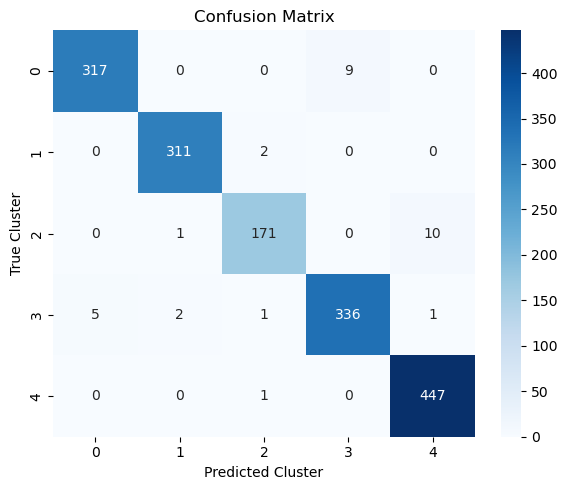

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Cluster')
plt.ylabel('True Cluster')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


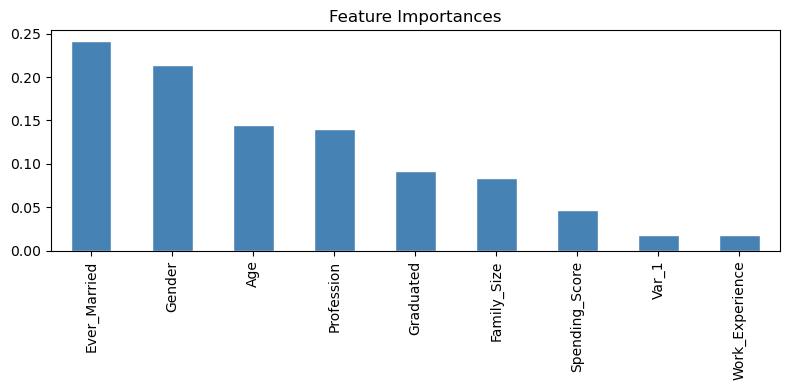

Ever_Married       0.241787
Gender             0.214101
Age                0.144261
Profession         0.140627
Graduated          0.091832
Family_Size        0.084009
Spending_Score     0.046720
Var_1              0.018398
Work_Experience    0.018266
dtype: float64


In [17]:
# Feature importance
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()
print(importances)


# Save Model

In [18]:
# Save model
with open('../models/classifier_model.pkl', 'wb') as f:
    pickle.dump(clf, f)

print('Saved classifier_model.pkl')

Saved classifier_model.pkl
